# fig6(fig.5.eps) Robustness

In [1]:
%pwd

'/home/tzuhsuan/GitHub/QFoam/High-fidelity-Rydberg-control-Z-gates-with-time-optimal-pulses/Manuscript-figures'

In [2]:
import os
import glob
import time
from IPython.display import clear_output

from qutip import *
import math

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from rdquantum.pulse_shape import Saffman_shape
from rdquantum.fidelity import fidelity
from rdquantum.optimizer.de import de

# plt.rcParams["figure.figsize"] = [5.5, 6]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.linewidth"] = 2.50

T = np.arange(0, 101, 5) #(\mu K)
Omp = np.arange(-0.1, 0.12, 0.02)

In [3]:
Fi_Brr = []
Fi_Brr_2D = []

# Add Gaussian500_53S_5L_BrrX
root_dir = "Gaussian500_53S_5L_BrrX"
data_dir_prefix = "Gaussian500_53S_5L_Brr"
brr = [50]
for i in range(len(brr)):
    Fi_Brr.append(np.load("../{}/{}{}/out_roubustness.npy".format(root_dir, data_dir_prefix, brr[i]), allow_pickle=True))

# Add Gaussian500_DeltaX
root_dir = "Gaussian500_DeltaX"
data_dir_prefix = "Gaussian500_Delta"
brr = [2]
for i in range(len(brr)):
    Fi_Brr.append(np.load("../{}/{}{}/out_roubustness.npy".format(root_dir, data_dir_prefix, brr[i]), allow_pickle=True))

# Add Segmented500_53S_5L_BrrX
root_dir = "Segmented500_53S_5L_BrrX"
data_dir_prefix = "Segmented500_53S_5L_Brr"
brr = [50]
for i in range(len(brr)):
    Fi_Brr.append(np.load("../{}/{}{}/out_roubustness.npy".format(root_dir, data_dir_prefix, brr[i]), allow_pickle=True))

# Add Segmented500_DeltaX
root_dir = "Segmented500_DeltaX"
data_dir_prefix = "Segmented500_Delta"
brr = [2]
for i in range(len(brr)):
    Fi_Brr.append(np.load("../{}/{}{}/out_roubustness.npy".format(root_dir, data_dir_prefix, brr[i]), allow_pickle=True))

# Add Gaussian500_53S_5L_BrrX 2D plot
root_dir = "Gaussian500_53S_5L_BrrX"
data_dir_prefix = "Gaussian500_53S_5L_Brr"
brr = [50, 100, 250, 500]
for i in range(len(brr)):
    Fi_Brr_2D.append(np.load("../{}/{}{}/out_roubustness.npy".format(root_dir, data_dir_prefix, brr[i]), allow_pickle=True))

In [4]:
Fi_Brr[0][5]

array([0.99925676, 0.99928362, 0.99928333, 0.99927885, 0.99927143,
       0.99926245, 0.9992501 , 0.99924171, 0.99923012, 0.99921841,
       0.99920604, 0.99919325, 0.99917999, 0.99916622, 0.9991529 ,
       0.99913859, 0.99912487, 0.99911052, 0.99909452, 0.99908116,
       0.99906648])

In [5]:
len(Fi_Brr)

4

/tmp/ipykernel_38534/3194874858.py:2: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  axBrr50 = plt.subplot(3,2,1)


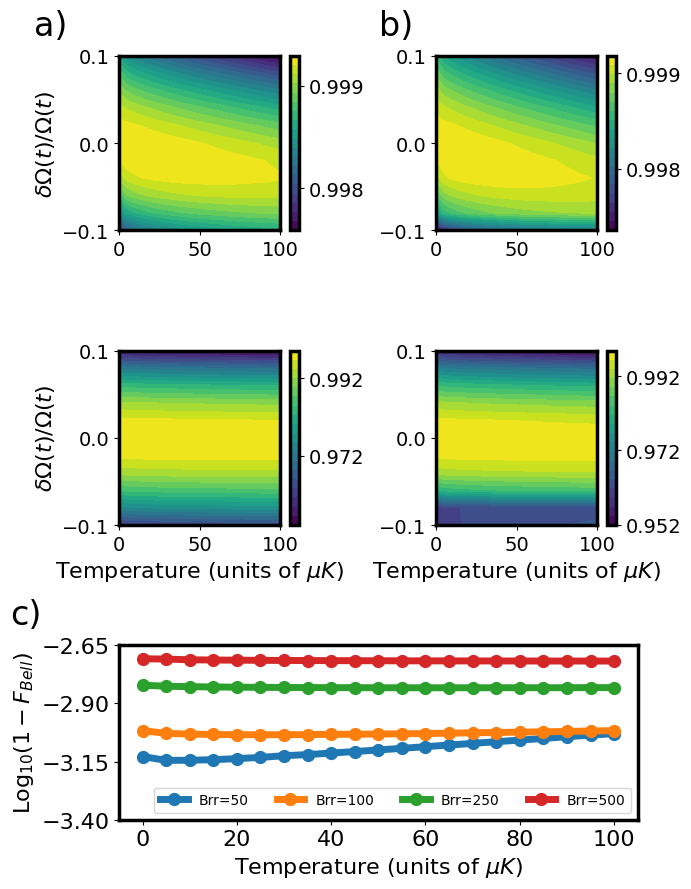

In [25]:
fig, axs = plt.subplots(figsize=(7, 9))
axBrr50 = plt.subplot(3,2,1)
axDelta2 = plt.subplot(3,2,3)
axBrr50seg = plt.subplot(3,2,2)
axDelta2seg = plt.subplot(3,2,4)
ax2d = plt.subplot(3,1,3)
# axBrr50 = plt.subplot2grid(shape=(11, 6), loc=(0, 0), colspan=3, rowspan=3)
# axDelta2 = plt.subplot2grid(shape=(11, 6), loc=(4, 0), colspan=3, rowspan=3)
# axBrr50seg = plt.subplot2grid(shape=(11, 6), loc=(0, 3), colspan=3, rowspan=3)
# axDelta2seg = plt.subplot2grid(shape=(11, 6), loc=(4, 3), colspan=3, rowspan=3)
# ax2d = plt.subplot2grid(shape=(11, 6), loc=(8, 0), colspan=6, rowspan=3)

yinterval = np.arange(-0.1, 0.11, 0.1)

# Brr=50
z = Fi_Brr[0]
lv = np.linspace(np.min(z), np.max(z), 20)
csBrr50 = axBrr50.contourf(T, Omp, z,levels=lv)
axBrr50.set_yticks(yinterval)
axBrr50.tick_params(axis='x', labelsize=14)
axBrr50.tick_params(axis='y', labelsize=14)
# axBrr50.set_xlabel('Temperature' ' (units of ' r'$\mu K$' ')', fontsize=16)
axBrr50.set_ylabel(r'$\delta \Omega(t) / \Omega(t)$', fontsize=16)
cbarBrr50 = fig.colorbar(csBrr50, ax=axBrr50, ticks=np.arange(0.996, 0.999, 0.001))
cbarBrr50.ax.tick_params(rotation=0, labelsize=14)
axBrr50.set_title('a)', x=-0.425, pad=15, fontsize=24)


# Delta=2
z = Fi_Brr[1]
lv = np.linspace(np.min(z), np.max(z), 20)
csDelta2 = axDelta2.contourf(T, Omp, z,levels=lv)
axDelta2.set_yticks(yinterval)
axDelta2.tick_params(axis='x', labelsize=14)
axDelta2.tick_params(axis='y', labelsize=14)
axDelta2.set_xlabel('Temperature' ' (units of ' r'$\mu K$' ')', fontsize=16)
axDelta2.set_ylabel(r'$\delta \Omega(t) / \Omega(t)$', fontsize=16)
cbarDelta2 = fig.colorbar(csDelta2, ax=axDelta2, ticks=np.arange(0.932, 0.999, 0.020))
cbarDelta2.ax.tick_params(rotation=0, labelsize=14)

# Seg Brr=50
z = Fi_Brr[2]
lv = np.linspace(np.min(z), np.max(z), 20)
csBrr50seg = axBrr50seg.contourf(T, Omp, z,levels=lv)
axBrr50seg.set_yticks(yinterval)
axBrr50seg.tick_params(axis='x', labelsize=14)
axBrr50seg.tick_params(axis='y', labelsize=14)
# axBrr50.set_xlabel('Temperature' ' (units of ' r'$\mu K$' ')', fontsize=16)
# axBrr50seg.set_ylabel(r'$\delta \Omega(t) / \Omega(t)$', fontsize=16)
cbarBrr50seg = fig.colorbar(csBrr50seg, ax=axBrr50seg, ticks=np.arange(0.996, 0.999, 0.001))
cbarBrr50seg.ax.tick_params(rotation=0, labelsize=14)
axBrr50seg.set_title('b)', x=-0.25, pad=15, fontsize=24)


# Seg Delta=2
z = Fi_Brr[3]
lv = np.linspace(np.min(z), np.max(z), 20)
csDelta2seg = axDelta2seg.contourf(T, Omp, z,levels=lv)
axDelta2seg.set_yticks(yinterval)
axDelta2seg.tick_params(axis='x', labelsize=14)
axDelta2seg.tick_params(axis='y', labelsize=14)
axDelta2seg.set_xlabel('Temperature' ' (units of ' r'$\mu K$' ')', fontsize=16)
# axDelta2seg.set_ylabel(r'$\delta \Omega(t) / \Omega(t)$', fontsize=16)
cbarDelta2seg = fig.colorbar(csDelta2seg, ax=axDelta2seg, ticks=np.arange(0.952, 0.999, 0.020))
cbarDelta2seg.ax.tick_params(rotation=0, labelsize=14)


# Delta2_2D
for i in range(len(Fi_Brr_2D)):
    ax2d.plot(T, [np.log10(1-x) for x in Fi_Brr_2D[i][5]], '-o', markersize=8.5, linewidth=5, label="Brr={}".format(brr[i]))
yinterval_2d = np.arange(-3.4, -2.55, 0.25)
ax2d.set_yticks(yinterval_2d)
ax2d.tick_params(axis='x', labelsize=16)
ax2d.tick_params(axis='y', labelsize=16)
ax2d.legend(loc='lower right', ncol=4, fontsize=10)
ax2d.set_xlabel('Temperature' ' (units of ' r'$\mu K$' ')', fontsize=16)
ax2d.set_ylabel('Log' r'$_{10}$' r'$(1-F_{Bell})$', fontsize=16)
ax2d.set_title('c)', x=-0.18, pad=15, fontsize=24)

plt.tight_layout()
plt.savefig('fig5.eps', dpi=1200)